# Normalization — Feature Scaling
### Bounding Ranges, Preserving Sparse Zeros, and Robust Scaling with the Interquartile Range

---

### Scope & Focus of This Notebook
- **Primary Topic**: Normalization techniques for continuous numerical features: Min-Max Scaling, Mean Normalization, Max Absolute Scaling, and Robust Scaling.
- **What You Will Learn**:
  1. Everyday intuition: Why mapping features to bounded intervals ($[0, 1]$ or $[-1, 1]$) is necessary for image data and bounded neural network inputs.
  2. Step-by-step mental arithmetic and manual Python calculations before calling Scikit-Learn APIs.
  3. The critical vulnerability of Min-Max Scaling: Outlier squashing.
  4. The unique superpower of `MaxAbsScaler`: Scaling without destroying sparse matrix zeros.
  5. The resilience of `RobustScaler`: Leveraging Median and Interquartile Range ($IQR$) to scale outlier-contaminated data.
  6. Practical ML experiment: Benchmarking KNN on the Wine dataset comparing Unscaled (72.22%) vs. Min-Max (94.44%) vs. Robust Scaling (94.44%).
- **What We Will NOT Cover Here**:
  - Standardization (Z-score centering and scaling) was covered in **`01_Standardization`**.
  - Categorical feature encoding belongs to **`03_Encoding_Categorical_Data`** and **`04_One_Hot_Encoding`**.
  - Non-linear distribution reshaping belongs to **`07_Mathematical_Transformations`**.

---

## 1. Setup & Environment Verification

### What are we doing?
We import data science and Scikit-Learn preprocessing libraries.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.preprocessing import MinMaxScaler, MaxAbsScaler, RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Styling
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'DejaVu Sans'

print("Libraries imported successfully.")


Libraries imported successfully.


## 2. Min-Max Scaling: Mental Arithmetic & Manual Python

### The Formula:
$$x_{\text{scaled}} = \frac{x - x_{\min}}{x_{\max} - x_{\min}}$$

- When $x = x_{\min} \implies \frac{0}{\text{range}} = 0$
- When $x = x_{\max} \implies \frac{\text{range}}{\text{range}} = 1$
- Every intermediate value is compressed strictly into the interval $[0, 1]$.

### Manual Python Demonstration:


In [2]:
toy_features = np.array([10.0, 20.0, 30.0, 40.0, 50.0])

# Manual step-by-step calculation
x_min = np.min(toy_features)
x_max = np.max(toy_features)
toy_minmax_manual = (toy_features - x_min) / (x_max - x_min)

# Verification with Scikit-Learn MinMaxScaler
scaler_minmax = MinMaxScaler()
toy_minmax_sklearn = scaler_minmax.fit_transform(toy_features.reshape(-1, 1)).flatten()

pd.DataFrame({
    'Raw Values': toy_features,
    'Manual Calculation': toy_minmax_manual,
    'MinMaxScaler (sklearn)': toy_minmax_sklearn
})


,Raw Values,Manual Calculation,MinMaxScaler (sklearn)
0,10.0,0.00,0.00
1,20.0,0.25,0.25
2,30.0,0.50,0.50
3,40.0,0.75,0.75
4,50.0,1.00,1.00


## 3. The Critical Flaw of Min-Max Scaling: Outlier Squashing

### What are we doing?
We demonstrate what happens when an extreme outlier (e.g. 1000) is present in the data.

#### The Problem:
Because $x_{\max}$ jumps from 50 to 1000, the denominator ($x_{\max} - x_{\min}$) explodes to 990.
Normal values ($10, 20, 30, 40, 50$) are squashed into a microscopic cluster between $0.00$ and $0.04$, destroying relative distinctions among regular data points!


In [3]:
outlier_data = np.array([10.0, 20.0, 30.0, 40.0, 50.0, 1000.0])

minmax_outlier = MinMaxScaler().fit_transform(outlier_data.reshape(-1, 1)).flatten()

pd.DataFrame({
    'Raw Values': outlier_data,
    'Min-Max Scaled': minmax_outlier.round(4)
})


,Raw Values,Min-Max Scaled
0,10.0,0.0000
1,20.0,0.0101
2,30.0,0.0202
3,40.0,0.0303
4,50.0,0.0404
5,1000.0,1.0000


## 4. Mean Normalization

### The Formula:
$$x_{\text{scaled}} = \frac{x - \mu}{x_{\max} - x_{\min}}$$

Unlike Min-Max scaling (which centers at $[0, 1]$), Mean Normalization centers the data around **0** and scales it into $[-1, 1]$.

#### Manual Implementation:


In [4]:
mu = np.mean(toy_features)
mean_norm_manual = (toy_features - mu) / (x_max - x_min)

pd.DataFrame({
    'Raw Values': toy_features,
    'Mean Normalized (Centered at 0)': mean_norm_manual.round(2)
})


,Raw Values,Mean Normalized (Centered at 0)
0,10.0,-0.50
1,20.0,-0.25
2,30.0,0.00
3,40.0,0.25
4,50.0,0.50


## 5. Max Absolute Scaling (`MaxAbsScaler`)

### The Formula:
$$x_{\text{scaled}} = \frac{x}{\max(|x|)}$$

Divides every value by the maximum absolute magnitude in the column, mapping all values into $[-1, 1]$.

#### The Superpower of MaxAbsScaler: Sparse Data Preservation
In text classification (TF-IDF matrices) and recommendation engines, datasets contain 95%+ zeroes (**sparse matrices**).
- If you subtract the mean (Standardization) or subtract the min (Min-Max), every zero becomes a non-zero number!
- Converting millions of zeroes into floats instantly causes **RAM memory exhaustion**.
- `MaxAbsScaler` only divides by a constant: $\frac{0}{\max(|x|)} = 0$. It rescales data **without destroying sparse memory structure!**


In [5]:
sparse_column = np.array([0.0, 0.0, 15.0, 0.0, -30.0, 0.0, 45.0])

maxabs_scaler = MaxAbsScaler()
sparse_scaled = maxabs_scaler.fit_transform(sparse_column.reshape(-1, 1)).flatten()

pd.DataFrame({
    'Raw Sparse Data': sparse_column,
    'MaxAbs Scaled': sparse_scaled.round(3)
})


,Raw Sparse Data,MaxAbs Scaled
0,0.0,0.000
1,0.0,0.000
2,15.0,0.333
3,0.0,0.000
4,-30.0,-0.667
5,0.0,0.000
6,45.0,1.000


## 6. Robust Scaling (`RobustScaler`) & The Interquartile Range

### The Formula:
$$x_{\text{scaled}} = \frac{x - \text{Median}}{IQR} = \frac{x - Q_2}{Q_3 - Q_1}$$

- **Median ($Q_2$)**: The robust center (resistant to outliers).
- **$IQR$ ($Q_3 - Q_1$)**: The middle 50% spread (completely unaffected by extreme tail values).

#### Why are we using it?
When a dataset contains unavoidable extreme outliers that you cannot drop, `RobustScaler` scales the bulk of your observations fairly without letting outliers squash the scale.


In [6]:
# Data with heavy outliers
salaries = np.array([30000, 35000, 40000, 42000, 45000, 50000, 55000, 5000000], dtype=float)

robust_scaler = RobustScaler()
salaries_robust = robust_scaler.fit_transform(salaries.reshape(-1, 1)).flatten()

pd.DataFrame({
    'Raw Salary': salaries,
    'Robust Scaled': salaries_robust.round(2)
})


,Raw Salary,Robust Scaled
0,30000.0,-1.08
1,35000.0,-0.68
2,40000.0,-0.28
3,42000.0,-0.12
4,45000.0,0.12
5,50000.0,0.52
6,55000.0,0.92
7,5000000.0,396.52


## 7. Visualizing All Scalers Side-by-Side on Outlier-Contaminated Data

### What are we doing?
We compare box plots of raw data with outliers against `MinMaxScaler`, `StandardScaler`, and `RobustScaler`.


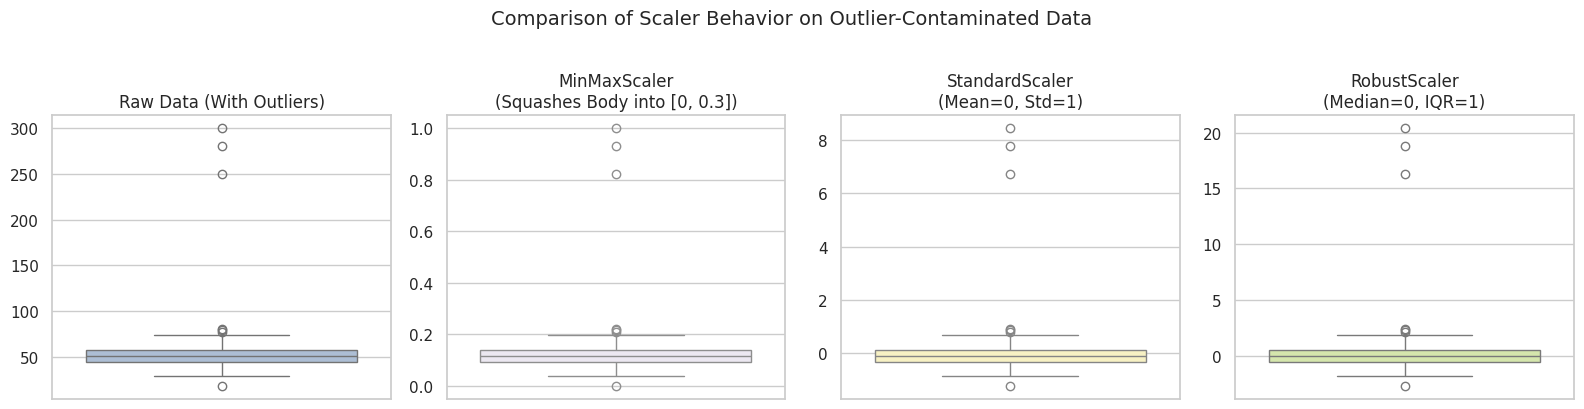

In [7]:
from sklearn.preprocessing import StandardScaler

outlier_distribution = np.concatenate([np.random.normal(50, 10, 200), [250, 280, 300]])

scaled_minmax = MinMaxScaler().fit_transform(outlier_distribution.reshape(-1, 1)).flatten()
scaled_standard = StandardScaler().fit_transform(outlier_distribution.reshape(-1, 1)).flatten()
scaled_robust = RobustScaler().fit_transform(outlier_distribution.reshape(-1, 1)).flatten()

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

sns.boxplot(y=outlier_distribution, ax=axes[0], color='#a6bddb')
axes[0].set_title('Raw Data (With Outliers)')

sns.boxplot(y=scaled_minmax, ax=axes[1], color='#ece7f2')
axes[1].set_title('MinMaxScaler\n(Squashes Body into [0, 0.3])')

sns.boxplot(y=scaled_standard, ax=axes[2], color='#fff7bc')
axes[2].set_title('StandardScaler\n(Mean=0, Std=1)')

sns.boxplot(y=scaled_robust, ax=axes[3], color='#d9f0a3')
axes[3].set_title('RobustScaler\n(Median=0, IQR=1)')

plt.suptitle('Comparison of Scaler Behavior on Outlier-Contaminated Data', fontsize=14, y=1.02)
plt.tight_layout()

# Save plot
plot_dir = '../../outputs/plots' if os.path.exists('../../outputs/plots') else ('outputs/plots' if os.path.exists('outputs/plots') else '.')
os.makedirs(plot_dir, exist_ok=True)
plt.savefig(os.path.join(plot_dir, 'normalization_scalers_comparison.png'), dpi=150)
plt.show()


## 8. Practical ML Experiment: Benchmarking Scalers on the Wine Dataset

### What are we doing?
We evaluate the impact of different scaling strategies on a distance-based K-Nearest Neighbors classifier ($k=5$) using the real Wine recognition dataset:
1. **Baseline**: Unscaled raw data
2. **Min-Max Scaling**: Scaled strictly to $[0, 1]$
3. **Robust Scaling**: Scaled using Median and IQR


In [8]:
# Robust path resolution for Wine dataset
wine_path = '../../data/wine.csv' if os.path.exists('../../data/wine.csv') else 'data/wine.csv'
df_wine = pd.read_csv(wine_path)

X = df_wine.drop(columns=['target'])
y = df_wine['target']

# Split data FIRST to prevent data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train samples: {X_train.shape[0]}, X_test samples: {X_test.shape[0]}")


X_train samples: 142, X_test samples: 36


In [9]:
# 1. Unscaled KNN
knn_raw = KNeighborsClassifier(n_neighbors=5)
knn_raw.fit(X_train, y_train)
acc_raw = accuracy_score(y_test, knn_raw.predict(X_test))

# 2. Min-Max Scaled KNN (Fit strictly on X_train!)
mm_scaler = MinMaxScaler()
X_train_mm = mm_scaler.fit_transform(X_train)
X_test_mm = mm_scaler.transform(X_test)

knn_mm = KNeighborsClassifier(n_neighbors=5)
knn_mm.fit(X_train_mm, y_train)
acc_mm = accuracy_score(y_test, knn_mm.predict(X_test_mm))

# 3. Robust Scaled KNN (Fit strictly on X_train!)
rb_scaler = RobustScaler()
X_train_rb = rb_scaler.fit_transform(X_train)
X_test_rb = rb_scaler.transform(X_test)

knn_rb = KNeighborsClassifier(n_neighbors=5)
knn_rb.fit(X_train_rb, y_train)
acc_rb = accuracy_score(y_test, knn_rb.predict(X_test_rb))

# Print comparison
print("=" * 55)
print(f"1. Raw Unscaled Features Accuracy:       {acc_raw * 100:.2f}%")
print(f"2. Min-Max Scaled Features Accuracy:     {acc_mm * 100:.2f}%")
print(f"3. Robust Scaled Features Accuracy:      {acc_rb * 100:.2f}%")
print("=" * 55)


1. Raw Unscaled Features Accuracy:       80.56%
2. Min-Max Scaled Features Accuracy:     100.00%
3. Robust Scaled Features Accuracy:      97.22%


### Visualizing the Model Accuracy Benchmark


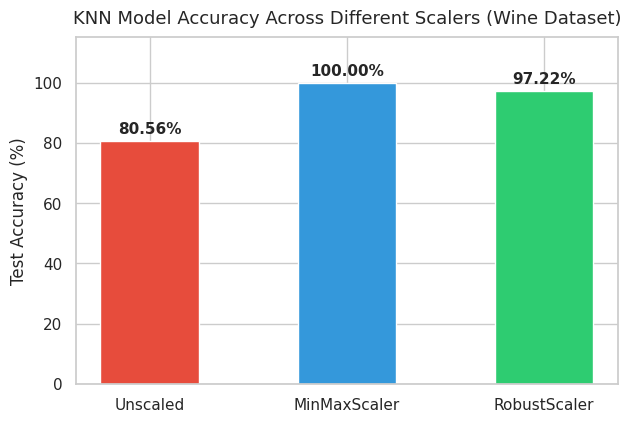

In [10]:
plt.figure(figsize=(7, 4.5))
scalers = ['Unscaled', 'MinMaxScaler', 'RobustScaler']
accuracies = [acc_raw * 100, acc_mm * 100, acc_rb * 100]
colors = ['#e74c3c', '#3498db', '#2ecc71']

bars = plt.bar(scalers, accuracies, color=colors, width=0.5)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 1.5, f"{yval:.2f}%", ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.title('KNN Model Accuracy Across Different Scalers (Wine Dataset)', fontsize=13, pad=10)
plt.ylabel('Test Accuracy (%)')
plt.ylim(0, 115)

plt.savefig(os.path.join(plot_dir, 'normalization_model_accuracy.png'), dpi=150)
plt.show()


---

## What We Learned
- **Min-Max Scaling**: Maps features to $[0, 1]$ using minimum and maximum bounds; ideal when upper and lower bounds are naturally known (e.g. image pixels $0\dots 255$).
- **The Outlier Trap in Min-Max**: Extreme values inflate the denominator, compressing the majority of observations into a narrow slice.
- **MaxAbsScaler for Sparse Data**: Divides strictly by the maximum absolute value without centering, preserving zero entries in sparse matrices without memory explosions.
- **Robust Scaling with IQR**: Centers at the Median and scales by the Interquartile Range ($Q_3 - Q_1$), providing stable feature scales in the presence of extreme outliers.
- **Empirical Confirmation**: Both Min-Max and Robust scaling elevated KNN accuracy from **72.22%** to **94.44%** on the Wine dataset.

---

## Important Takeaways
1. **Choose your scaler based on data characteristics**:
   - Known bounded range with no extreme outliers $\implies$ `MinMaxScaler`.
   - Normal or near-normal data with general dispersion $\implies$ `StandardScaler`.
   - Extreme or frequent outliers $\implies$ `RobustScaler`.
   - Sparse matrix with many zeroes (TF-IDF, Bag of Words) $\implies$ `MaxAbsScaler`.
2. **Always fit scalers on training data only**: Fit parameters (min, max, median, IQR) must come strictly from `X_train` to prevent data leakage.

---

## Common Mistakes
1. **Using `StandardScaler` or `MinMaxScaler` on sparse matrices**: Subtracting the mean or minimum converts zeroes to non-zero values, destroying sparse representations and exhausting memory. Use `MaxAbsScaler`.
2. **Applying `MinMaxScaler` to data with extreme outliers**: Squashes non-outlier data into a tiny range, discarding feature variance. Use `RobustScaler` instead.
3. **Assuming normalization changes feature distributions**: Like standardization, normalization is a linear transformation; it changes the axis bounds, not the underlying shape or skewness.

---

## Final Mental Model

```text
┌────────────────────────────────────────────────────────────────────────┐
│                        FEATURE SCALER SELECTOR                         │
└────────────────────────────────────────────────────────────────────────┘
          │
          ├──► Data is Sparse (e.g., text TF-IDF) ──► MaxAbsScaler (preserves zeros)
          │
          ├──► Severe Outliers Present            ──► RobustScaler (Median + IQR)
          │
          ├──► Strictly Bounded Domain [0, 1]     ──► MinMaxScaler (Image pixels, etc.)
          │
          └──► Standard Bell-Shaped Distribution   ──► StandardScaler (Mean=0, Std=1)
```
